Raw Shape: (27529, 7)
After Cleaning Shape: (27529, 7)

--- Anomaly Detection ---
anomaly
 1    26159
-1     1370
Name: count, dtype: int64


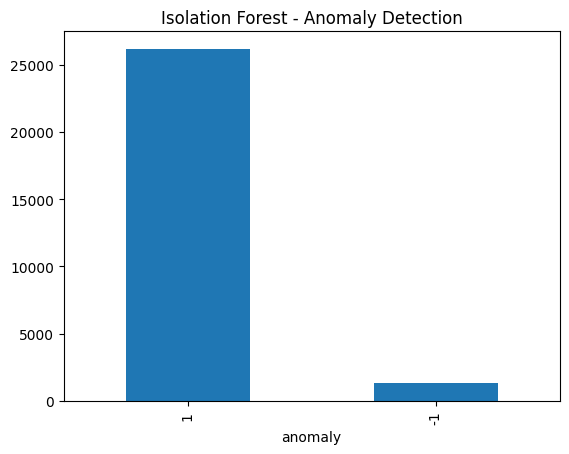


--- Clustering Evaluation ---
Silhouette Score: 0.6273815897123212
Davies-Bouldin Index: 0.427652314846001
Calinski-Harabasz Score: 11934.705717411709


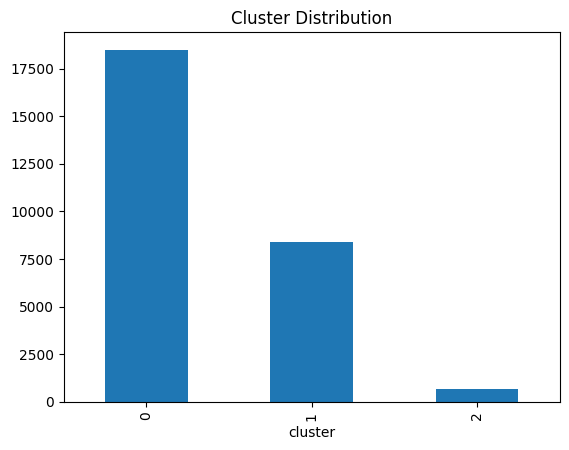

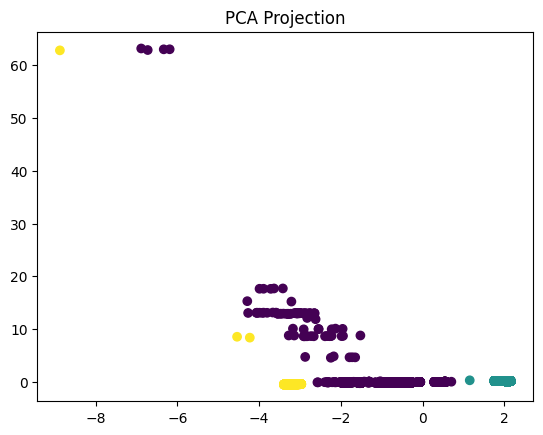

Explained Variance Ratio: [0.33622853 0.20222422]
Total Variance Captured: 0.5384527503891694
Class Distribution:
label
0    19146
1     8383
Name: count, dtype: int64

--- Random Forest ---
Accuracy: 0.9996367598982928
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3829
           1       1.00      1.00      1.00      1677

    accuracy                           1.00      5506
   macro avg       1.00      1.00      1.00      5506
weighted avg       1.00      1.00      1.00      5506


--- Logistic Regression ---
Accuracy: 0.9992735197965855
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3829
           1       1.00      1.00      1.00      1677

    accuracy                           1.00      5506
   macro avg       1.00      1.00      1.00      5506
weighted avg       1.00      1.00      1.00      5506



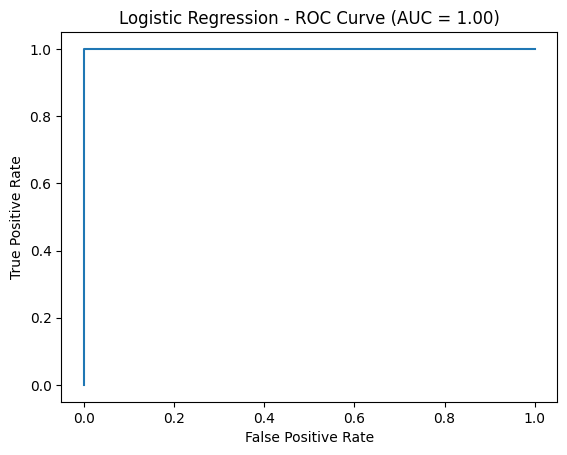

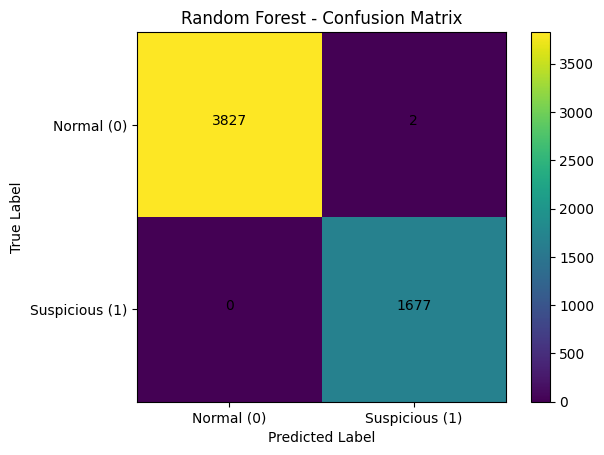

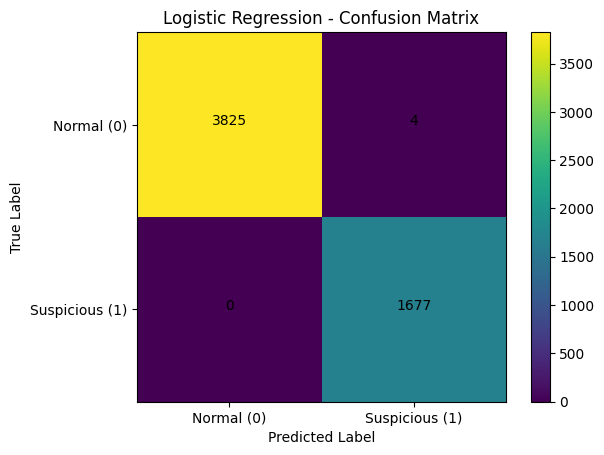


--- Model Comparison ---
Random Forest AUC: 1.0
Logistic Regression AUC: 0.9994390485441036

Best Parameters: {'max_depth': None, 'n_estimators': 100}


In [11]:

# REAL-TIME ATTACK DETECTION USING DIONAEA CLEAN2 DATASET

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_curve, auc,
    silhouette_score, davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# STEP 1: LOAD DATASET

file_path = "/content/dionaeaClean2.csv"

df = pd.read_csv(
    file_path,
    sep=",",
    skipinitialspace=True,
    on_bad_lines='skip',
    index_col=False
)

print("Raw Shape:", df.shape)

# STEP 2: CLEANING

df.drop_duplicates(inplace=True)

df["dst_port"] = pd.to_numeric(df["dst_port"], errors='coerce')
df["src_port"] = pd.to_numeric(df["src_port"], errors='coerce')
df = df[(df["dst_port"] >= 0) & (df["dst_port"] <= 65535)]

df["protocol"] = df["protocol"].astype(str).str.lower().str.strip()
df["transport"] = df["transport"].astype(str).str.lower().str.strip()
df["type"] = df["type"].astype(str).str.lower().str.strip()

df["timestamp"] = pd.to_datetime(df["timestamp"], errors='coerce')

print("After Cleaning Shape:", df.shape)

# STEP 3: FEATURE ENGINEERING

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

ip_attempts = df.groupby("src_ip").size().reset_index(name="total_attempts")
df = df.merge(ip_attempts, on="src_ip", how="left")

unique_ports = df.groupby("src_ip")["dst_port"].nunique().reset_index(name="unique_ports")
df = df.merge(unique_ports, on="src_ip", how="left")

# Encoding
le = LabelEncoder()
df["protocol_encoded"] = le.fit_transform(df["protocol"])
df["transport_encoded"] = le.fit_transform(df["transport"])

# STEP 4: PREPARE FEATURES

features = [
    "dst_port", "src_port", "hour",
    "total_attempts", "unique_ports",
    "protocol_encoded", "transport_encoded"
]

X = df[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ================= UNSUPERVISED LEARNING ==================

# ---------------- Isolation Forest ----------------

iso = IsolationForest(contamination=0.05, random_state=42)
df["anomaly"] = iso.fit_predict(X_scaled)

print("\n--- Anomaly Detection ---")
print(df["anomaly"].value_counts())

plt.figure()
df["anomaly"].value_counts().plot(kind="bar")
plt.title("Isolation Forest - Anomaly Detection")
plt.show()

# ---------------- K-Means ----------------

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df["cluster"])
db_score = davies_bouldin_score(X_scaled, df["cluster"])
ch_score = calinski_harabasz_score(X_scaled, df["cluster"])

print("\n--- Clustering Evaluation ---")
print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_score)
print("Calinski-Harabasz Score:", ch_score)

plt.figure()
df["cluster"].value_counts().plot(kind="bar")
plt.title("Cluster Distribution")
plt.show()

# ---------------- PCA ----------------

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"])
plt.title("PCA Projection")
plt.show()

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Captured:", sum(pca.explained_variance_ratio_))

# SAFE LABEL CREATION (NO FAILURE VERSION)

mean_attempts = df["total_attempts"].mean()
std_attempts = df["total_attempts"].std()

threshold = mean_attempts + std_attempts

df["label"] = np.where(df["total_attempts"] > threshold, 1, 0)

print("Class Distribution:")
print(df["label"].value_counts())

# Safety check
if len(df["label"].unique()) < 2:
    print("Adjusting threshold automatically...")
    threshold = df["total_attempts"].median()
    df["label"] = np.where(df["total_attempts"] > threshold, 1, 0)
    print("New Class Distribution:")
    print(df["label"].value_counts())

# SUPERVISED LEARNING (NO LEAKAGE)

features_sup = [
    "dst_port", "src_port", "hour",
    "unique_ports",
    "protocol_encoded", "transport_encoded"
]

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_sup = imputer.fit_transform(df[features_sup])

scaler = StandardScaler()
X_sup = scaler.fit_transform(X_sup)

y_sup = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_sup, y_sup,
    test_size=0.2,
    random_state=42,
    stratify=y_sup
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("\n--- Random Forest ---")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

print("\n--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

from sklearn.metrics import roc_curve, auc

# ROC for Logistic Regression
fpr2, tpr2, _ = roc_curve(y_test, lr_prob)
roc_auc2 = auc(fpr2, tpr2)

plt.figure()
plt.plot(fpr2, tpr2)
plt.title("Logistic Regression - ROC Curve (AUC = %0.2f)" % roc_auc2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, title):
    plt.figure()
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["Normal (0)", "Suspicious (1)"])
    plt.yticks(tick_marks, ["Normal (0)", "Suspicious (1)"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j],
                     horizontalalignment="center")

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
plot_confusion_matrix(cm_rf, "Random Forest - Confusion Matrix")

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
plot_confusion_matrix(cm_lr, "Logistic Regression - Confusion Matrix")

# ---------------- Performance Comparison ----------------

print("\n--- Model Comparison ---")
print("Random Forest AUC:", roc_auc)
print("Logistic Regression AUC:", roc_auc2)

# ---------------- Hyperparameter Tuning ----------------

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)